In [156]:
### importing necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [157]:
pd.set_option("display.max_columns", None)  # Show all columns
pd.set_option("display.width", 1000)  # Adjust width for better visibility


In [158]:
# due to the large size of file we Load in chunks to avoid memory issues
chunksize = 1000000  
data_chunkz = []
for chunk in pd.read_csv('data.csv', chunksize=chunksize, low_memory=False):
    data_chunkz.append(chunk)
data = pd.concat(data_chunkz, axis=0)

del data_chunkz 

In [159]:
#view the first five rows
data.head(5)

,bid,channel,createdon,cust_name,date_of_birth,email,email_domain_score,email_score,godate,insurance_flg,ip,isFraud,nationality,netprice_thb,p_attempts,paidon,passenger_passport_score,passenger_score,payer_country,payer_name,proxy,recent_abuse,role_id,seats,tor,useragent,usr_name,vehclass_id,vpn
0,6524445,affiliate,2021-05-01 00:21:17+07:00,Tiffany Stephenson,1999-07-04,ryanbrianna@outlook.com,0.0,10.0,2021-07-01 07:30:00+07:00,0,213.89.6.2,0,SE,115.000000,0,2021-06-29 16:57:12.177348+07:00,0.0,0.0,SE,Tiffany Stephenson,NaN,NaN,user,1,NaN,"Phone,sv,SEK",Tiffany Stephenson,van,NaN
1,5800338,affiliate,2021-05-01 00:30:19+07:00,Amanda Cooper,2002-06-07,dustin85@gmail.com,0.0,10.0,2021-05-29 13:35:00+07:00,1,124.106.133.175,0,TH,985.180176,0,2021-05-25 03:58:15.692073+07:00,0.0,0.0,NU,NaN,0.0,0.0,user,1,0.0,"Phone,en,PHP",Amanda Cooper,avia,0.0
2,7897646,direct,2021-05-01 01:09:12+07:00,Victoria Cortez,NaN,johnny40@gmail.com,0.0,2.0,2021-05-10 10:40:00+07:00,1,183.88.101.237,0,TH,2400.000000,7,2021-05-05 18:40:55.424451+07:00,0.0,0.0,CH,Victoria Cortez,NaN,NaN,user,2,NaN,"Phone,de,THB",Victoria Cortez,avia,NaN
3,7644834,direct,2021-05-01 01:29:33+07:00,Victoria Cortez,1995-08-02,johnny40@gmail.com,0.0,2.0,2021-05-10 12:00:00+07:00,1,183.88.101.237,0,TH,410.000000,2,2021-05-06 04:07:31.171406+07:00,0.0,0.0,CH,Victoria Cortez,NaN,NaN,user,2,NaN,"Phone,de,THB",Victoria Cortez,bus,NaN
4,7462960,NaN,2021-05-01 01:36:36+07:00,Francisco Wagner,1989-01-16,margaretcastaneda@gmail.com,0.0,5.0,2021-05-02 10:33:00+07:00,1,183.171.184.148,0,TH,573.537903,0,2021-04-27 17:24:15.421043+07:00,0.0,0.0,NU,NaN,0.0,0.0,user,1,0.0,"Phone,en,MYR",Francisco Wagner,train,0.0


In [160]:
#checking the number of rows to number of columns
data.shape

(3464222, 29)

In [161]:
data.info() ## checking data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3464222 entries, 0 to 3464221
Data columns (total 29 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   bid                       int64  
 1   channel                   object 
 2   createdon                 object 
 3   cust_name                 object 
 4   date_of_birth             object 
 5   email                     object 
 6   email_domain_score        float64
 7   email_score               float64
 8   godate                    object 
 9   insurance_flg             int64  
 10  ip                        object 
 11  isFraud                   int64  
 12  nationality               object 
 13  netprice_thb              float64
 14  p_attempts                int64  
 15  paidon                    object 
 16  passenger_passport_score  float64
 17  passenger_score           float64
 18  payer_country             object 
 19  payer_name                object 
 20  proxy                   

In [162]:
data.describe() ### statistical view of our data

,bid,email_domain_score,email_score,insurance_flg,isFraud,netprice_thb,p_attempts,passenger_passport_score,passenger_score,proxy,recent_abuse,seats,tor,vpn
count,3.464222e+06,3.464222e+06,3.464222e+06,3.464222e+06,3.464222e+06,3.464222e+06,3.464222e+06,3.464222e+06,3.464222e+06,1.755741e+06,1.755741e+06,3.464222e+06,1.755741e+06,1.755741e+06
mean,7.734663e+06,1.905190e-04,3.341505e+00,2.333981e-01,2.258804e-03,7.416636e+02,1.117096e-01,5.950254e-02,1.243714e-01,5.901058e-01,2.726758e-01,1.835898e+00,6.612593e-04,1.735552e-01
std,1.238598e+06,7.560115e-02,3.929717e+00,4.229935e-01,4.747318e-02,2.474322e+04,5.732293e-01,1.334742e+00,2.947970e+00,4.918141e-01,4.453356e-01,1.042537e+00,2.570647e-02,3.787267e-01
min,5.590536e+06,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-4.836959e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,6.661490e+06,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.600000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
50%,7.734956e+06,0.000000e+00,2.000000e+00,0.000000e+00,0.000000e+00,4.800000e+02,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,2.000000e+00,0.000000e+00,0.000000e+00
75%,8.807322e+06,0.000000e+00,5.000000e+00,0.000000e+00,0.000000e+00,8.000000e+02,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,0.000000e+00,0.000000e+00
max,9.880728e+06,3.000000e+01,1.000000e+01,1.000000e+00,1.000000e+00,1.731993e+07,1.440000e+02,3.000000e+01,7.000000e+01,1.000000e+00,1.000000e+00,1.400000e+02,1.000000e+00,1.000000e+00


In [163]:
data.nunique() #viewing unique values of our data

bid                         2376692
channel                           8
createdon                   3194833
cust_name                    402128
date_of_birth                 17754
email                        707406
email_domain_score                2
email_score                       4
godate                       273111
insurance_flg                     2
ip                          1221101
isFraud                           2
nationality                     225
netprice_thb                 472092
p_attempts                       49
paidon                      3464222
passenger_passport_score          2
passenger_score                   2
payer_country                   197
payer_name                   403973
proxy                             2
recent_abuse                      2
role_id                          15
seats                            28
tor                               2
useragent                      1844
usr_name                     356132
vehclass_id                 

In [164]:
#checking for the columns that have missing values in the dataset 
missing_values = data.isna().sum().sort_values(ascending=False)
missing_values = missing_values[missing_values > 0]
missing_values

vpn              1708481
tor              1708481
proxy            1708481
recent_abuse     1708481
payer_name       1296718
channel           118148
date_of_birth      35196
usr_name            5045
ip                   232
useragent            232
payer_country         74
nationality           41
cust_name              1
dtype: int64

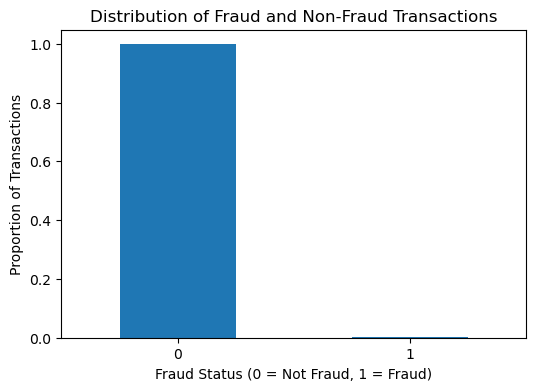

In [11]:
## plotting the distribution of the isFraud columns

plt.figure(figsize=(6, 4))  
data['isFraud'].value_counts(normalize=True).round(3).plot(kind="bar")
plt.xlabel("Fraud Status (0 = Not Fraud, 1 = Fraud)")
plt.ylabel("Proportion of Transactions")
plt.title("Distribution of Fraud and Non-Fraud Transactions")
plt.xticks(rotation=0) 
plt.show()

This shows us that we have an imbalanced dataset, where our majority class is far bigger than our minority class.

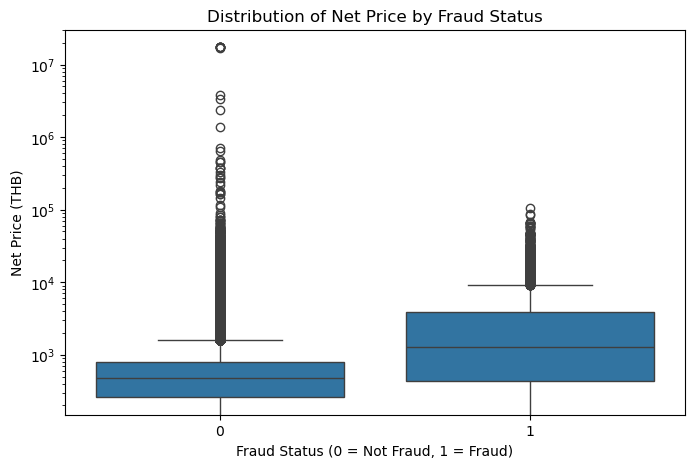

In [12]:
#visualizing the distribution of netprice_thb for both fraud (1) and non-fraud (0) transactions
plt.figure(figsize=(8, 5))
sns.boxplot(x=data["isFraud"], y=data["netprice_thb"])
plt.xlabel("Fraud Status (0 = Not Fraud, 1 = Fraud)")
plt.ylabel("Net Price (THB)")
plt.title("Distribution of Net Price by Fraud Status")
plt.yscale("log") 
plt.show()

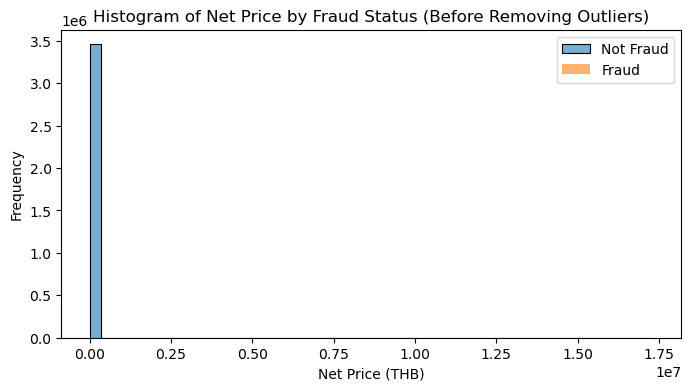

In [13]:
#  histogram for fraud and non-fraud cases
plt.figure(figsize=(8, 4))
sns.histplot(data[data["isFraud"] == 0]["netprice_thb"], bins=50,  label="Not Fraud", alpha=0.6)
sns.histplot(data[data["isFraud"] == 1]["netprice_thb"], bins=50, label="Fraud", alpha=0.6)
plt.xlabel("Net Price (THB)")
plt.ylabel("Frequency")
plt.title("Histogram of Net Price by Fraud Status (Before Removing Outliers)")
plt.legend()
plt.show()


We see it in the histogram and boxplot. The data is very skewed. So, in order to create a helpful boxplot, we need to use logging to preserve the data.

In [166]:
#logging our netprice_thb_log 
data["netprice_thb_log"] = np.log1p(data["netprice_thb"])

C:\Users\M.I.S SITHLTD\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


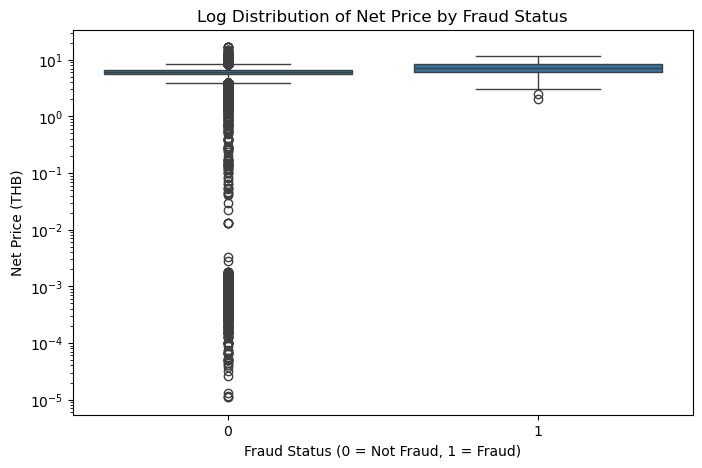

In [16]:
## plotting after logging the netprice
plt.figure(figsize=(8, 5))
sns.boxplot(x=data["isFraud"], y=data["netprice_thb_log"])
plt.xlabel("Fraud Status (0 = Not Fraud, 1 = Fraud)")
plt.ylabel("Net Price (THB)")
plt.title("Log Distribution of Net Price by Fraud Status")
plt.yscale("log") 
plt.show()

<Axes: >

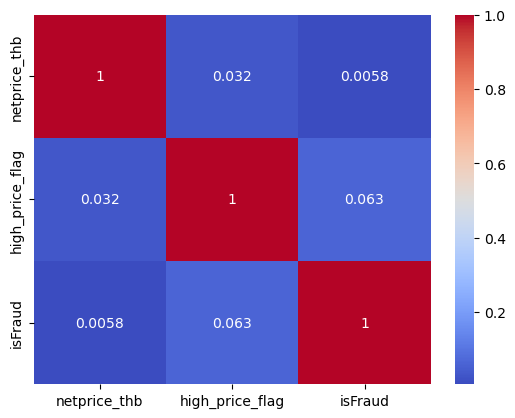

In [167]:
# Set a threshold for prices that are unusually high, based on the 90th percentile
threshold = data['netprice_thb'].quantile(0.90)  # Using the 90th percentile as the threshold
data['high_price_flag'] = (data['netprice_thb'] > threshold).astype(int)
corr_matrix = data[["netprice_thb", "high_price_flag","isFraud"]].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")

### To check if high_price_flag is significantly related to fraud we perform a Chi-Square Test (For Statistical Significance)

In [168]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(data['high_price_flag'], data['isFraud'])
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Test Statistic: {chi2}")
print(f"P-value: {p}")

Chi-Square Test Statistic: 13642.61742156997
P-value: 0.0


Since the p-value is less than 0.05, this confirms that high_price_flag and fraud occurrence are strongly associated and not due to random chance.

## We will extract useful features before removing  columns, as they could improve our model's performance.

In [169]:
#extracting age from the date of birth
data['age'] = 2025 - pd.to_datetime(data['date_of_birth']).dt.year
data['age'] = data['age'].fillna(data['age'].median())

C:\Users\M.I.S SITHLTD\AppData\Local\Temp\ipykernel_2996\1999779454.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_fraud_rate = data.groupby("age_group")["isFraud"].value_counts(normalize=True).unstack()


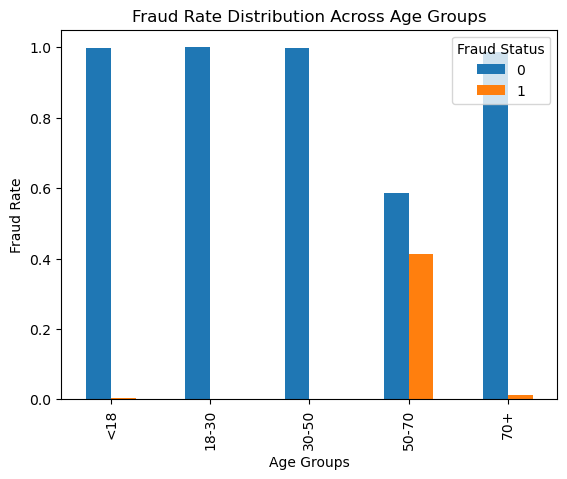

In [170]:
# Categorizing age into groups to analyze fraud trends.
data['age_group'] = pd.cut(data['age'], bins=[0, 18, 30, 50, 70, 100], labels=['<18', '18-30', '30-50', '50-70', '70+'])
age_fraud_rate = data.groupby("age_group")["isFraud"].value_counts(normalize=True).unstack()
age_fraud_rate.plot(kind="bar")
plt.xlabel("Age Groups")
plt.ylabel("Fraud Rate")
plt.title("Fraud Rate Distribution Across Age Groups")
plt.legend(title="Fraud Status")
plt.show();

C:\Users\M.I.S SITHLTD\AppData\Local\Temp\ipykernel_2996\2550584734.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = data.groupby(["age_group", "isFraud"])["netprice_thb"].sum().unstack()


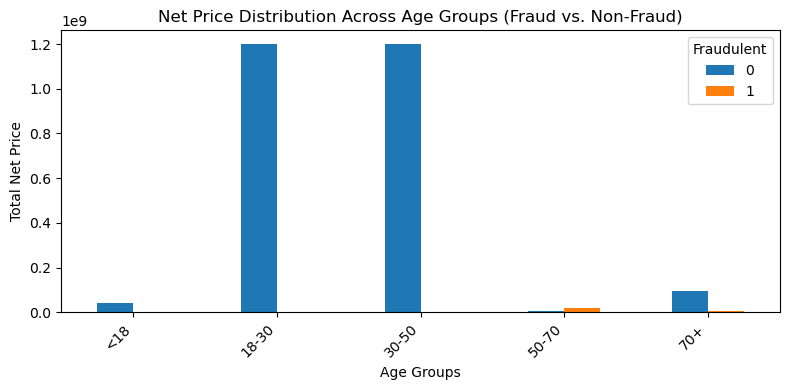

In [171]:
## The chart allows you to compare the total net price associated with fraudulent and non-fraudulent activities across different age groups.
grouped_data = data.groupby(["age_group", "isFraud"])["netprice_thb"].sum().unstack()
grouped_data.plot(kind="bar", figsize=(8, 4)) 
plt.xlabel("Age Groups")
plt.ylabel("Total Net Price")
plt.title("Net Price Distribution Across Age Groups (Fraud vs. Non-Fraud)")
plt.legend(title="Fraudulent") 
plt.xticks(rotation=45, ha='right') 
plt.tight_layout() 
plt.show()

### We will explore Isfraud with time and date

In [172]:
#convertion of the data types for these columns from object to data time
data["createdon"] = pd.to_datetime(data["createdon"], errors="coerce")
data["paidon"] = pd.to_datetime(data["paidon"], errors="coerce")
data["godate"] = pd.to_datetime(data["godate"], errors="coerce")

In [173]:
#extracting possible patterns that we might find between the days of customer interactions 
data['time_to_payment'] = (data['paidon'] - data['createdon']).dt.days # total time it took the customer to decide for payment
data['days_to_travel'] = (data['godate'] - data['createdon']).dt.total_seconds() / (24 * 3600) # no of days the customers have before travelling 

In [174]:
# extracting hourly transactions
data['booking_hour'] = data['createdon'].dt.hour
fraud_by_hour = data.groupby('booking_hour')['isFraud'].mean().reset_index()
fraud_by_hour.columns = ['booking_hour', 'fraud_rate']

C:\Users\M.I.S SITHLTD\AppData\Local\Temp\ipykernel_20520\547294991.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fraud_by_hour['booking_hour'], y=fraud_by_hour['fraud_rate'], palette="Reds")


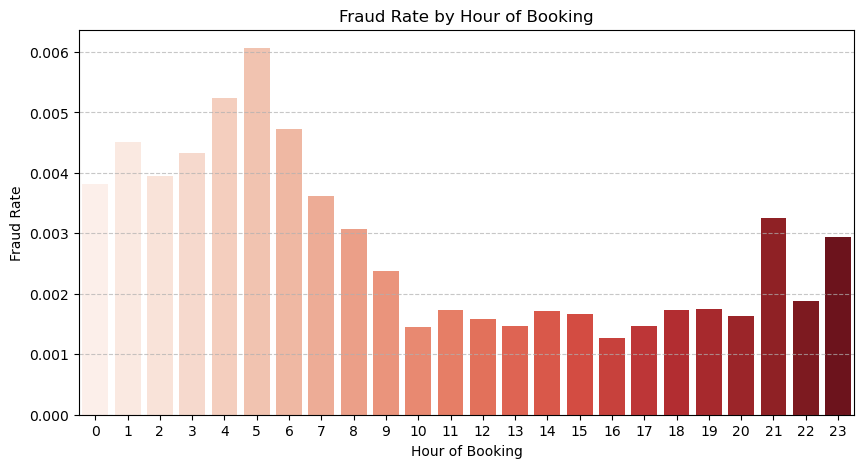

In [207]:
## The chart allows you to fraud activaties by hours 
plt.figure(figsize=(10, 5))
sns.barplot(x=fraud_by_hour['booking_hour'], y=fraud_by_hour['fraud_rate'], palette="Reds")
plt.xlabel("Hour of Booking")
plt.ylabel("Fraud Rate")
plt.title("Fraud Rate by Hour of Booking")
plt.xticks(range(0, 24))  # Ensure all hours are displayed
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Fraud rates peak in early morning hours, decline during the day, and slightly rise at night, suggesting fraudsters exploit less-monitored periods.

In [175]:
# Extract weekday (0 = Monday, 6 = Sunday)
data['weekday'] = data['createdon'].dt.weekday
# Group by weekday and calculate fraud rate
fraud_by_weekday = data.groupby('weekday')['isFraud'].mean().reset_index()

C:\Users\M.I.S SITHLTD\AppData\Local\Temp\ipykernel_2996\684021536.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fraud_by_weekday['weekday'], y=fraud_by_weekday['isFraud'], palette="coolwarm")


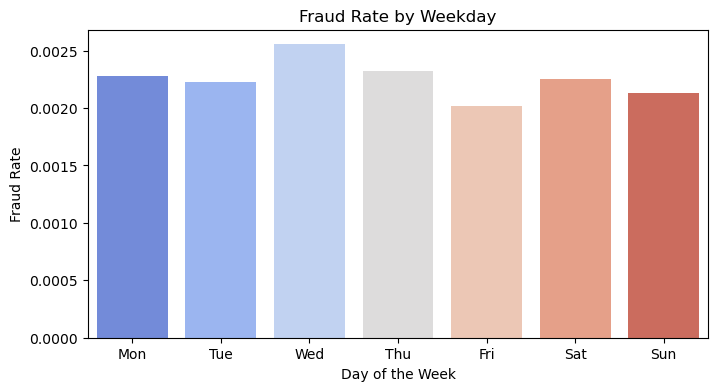

In [44]:

## The chart allows you to fraud activaties by weekdays 
plt.figure(figsize=(8, 4))
sns.barplot(x=fraud_by_weekday['weekday'], y=fraud_by_weekday['isFraud'], palette="coolwarm")
plt.xticks(ticks=range(7), labels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.xlabel("Day of the Week")
plt.ylabel("Fraud Rate")
plt.title("Fraud Rate by Weekday")
plt.show()

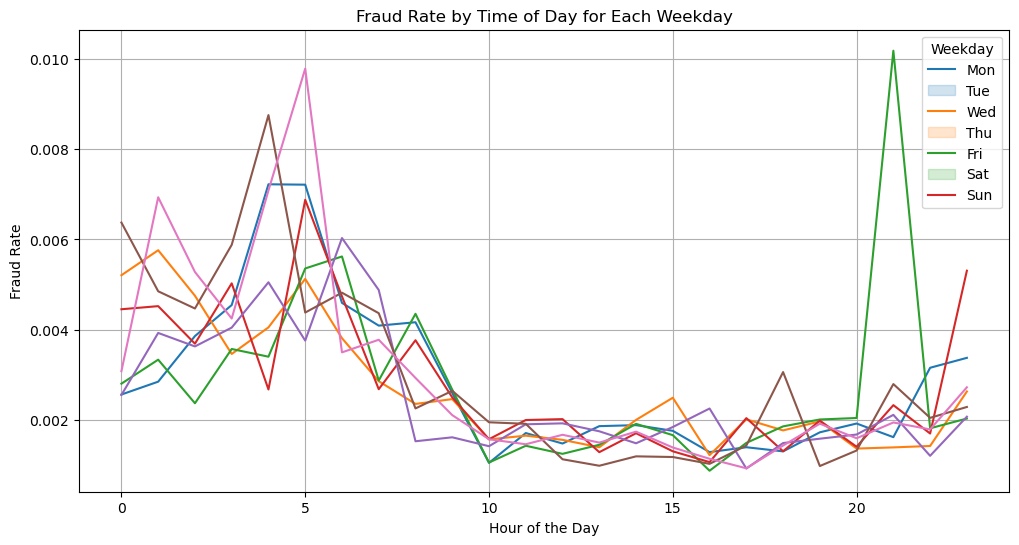

In [206]:
 # Grouping by weekday and booking hour to compute the fraud rate
fraud_by_hour_weekday = data.groupby(['weekday', 'booking_hour'])['isFraud'].mean().reset_index()
# Plotting  fraud rate by time of day for each weekday 
plt.figure(figsize=(12, 6))
sns.lineplot(data=fraud_by_hour_weekday, x='booking_hour', y='isFraud', hue='weekday', palette="tab10")
plt.title("Fraud Rate by Time of Day for Each Weekday")
plt.xlabel("Hour of the Day")
plt.ylabel("Fraud Rate")
plt.legend(title="Weekday", labels=["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
plt.grid()

plt.show()

## Evaluating Email Domain Analysis for Fraud Detection


Since the email address alone doesn’t provide much insight, we extracted the **domain** instead. Fraudsters often use **temporary or disposable email services** for transactions, making domain analysis a valuable feature for fraud detection. By exploring email domains, we aim to identify patterns that could indicate fraudulent activity.

In [177]:
## This line of code efficiently extracts the domain part of each email address in your DataFrame and stores it in a separate, readily accessible column
data['email_domain'] = data['email'].str.split('@').str[1]

In [178]:
## This categorizes email domains into several types (common, temporary, educational, governmental, or other)
common_domains = {'gmail.com', 'yahoo.com', 'hotmail.com', 'outlook.com'}
temp_email_domains = {'mailinator.com', 'tempmail.com', '10minutemail.com'}

def classify_email_domain(domain):
    if domain in common_domains:
        return 'common'
    elif domain in temp_email_domains:
        return 'temp'
    elif domain.endswith('.edu'):
        return 'edu'
    elif domain.endswith('.gov'):
        return 'gov'
    else:
        return 'other'

data['email_domain_type'] = data['email_domain'].apply(classify_email_domain)
data.groupby('email_domain_type')["isFraud"].value_counts()

email_domain_type  isFraud
common             0          2412081
                   1             6472
edu                0             5630
                   1               18
gov                0               37
other              0          1038641
                   1             1335
temp               0                8
Name: count, dtype: int64

In [179]:
##We identify email domains that are perfectly associated with fraudulent activity
fraud_rate_other = data[data['email_domain_type'] == 'other'].groupby('email_domain')['isFraud'].mean()
fraud_counts = data.groupby('email_domain')['isFraud'].agg(['mean', 'count'])
high_risk_domains = set(fraud_counts[fraud_counts['mean'] == 1.0].index)
data['high_risk_domain_flag'] = data['email_domain'].apply(lambda x: 1 if x in high_risk_domains else 0)
data['high_risk_domain_flag'].value_counts()

high_risk_domain_flag
0    3464054
1        168
Name: count, dtype: int64

##### We identify email domains with a 100% fraud rate based on the available data and creates a new feature, 'high_risk_domain_flag', to mark emails from these domains. This flag can then be used in a model to easily identify and potentially prioritize or handle emails from these high-risk domains.

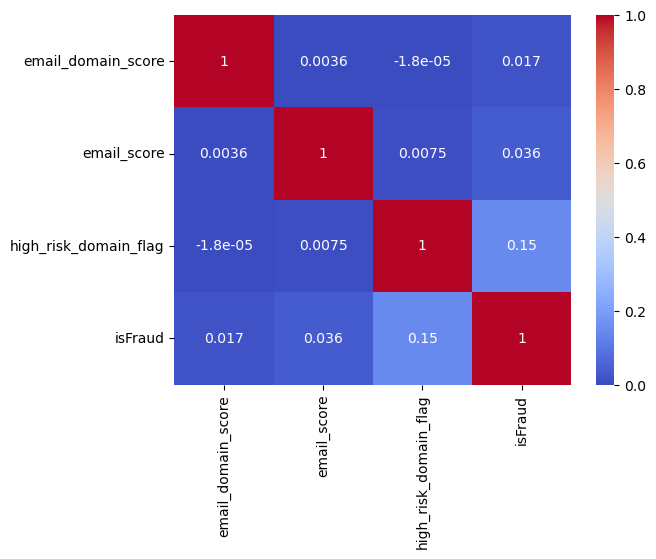

In [49]:
mail = data[['email_domain_score', 'email_score', 'high_risk_domain_flag','isFraud']].corr()
sns.heatmap(mail, annot=True, cmap="coolwarm");

The high_risk_domain_flag provides unique fraud detection insights beyond existing email-based features like email_domain_score and email_score. 
By visualizing correlations in a heatmap,we can determine if high_risk_domain_flag offers additional predictive value or if it is redundant with other email-related fraud indicators.
In which it does offers additional predictive value

### Assessing Fraud Likelihood Across User Roles :Identifying Roles with Higher Fraud Incidence Without Implying Causation

In [180]:
### We calculates the fraud rate for each role_id and then maps these fraud rates back
fraud_rates = data.groupby('role_id')['isFraud'].mean().reset_index()
fraud_rates.columns = ['role_id', 'fraud_rate']
fraud_rates = fraud_rates.sort_values(by='fraud_rate', ascending=False)
role_fraud_mapping = dict(fraud_rates.values)
data['role_fraud_rate'] = data['role_id'].map(role_fraud_mapping)

### Evaluating Anonymity Features for Fraud Detection

In [181]:
binary_features = ['vpn', 'tor', 'proxy', 'recent_abuse']
data[binary_features] = data[binary_features].fillna(0)  # Assume missing means 'No'

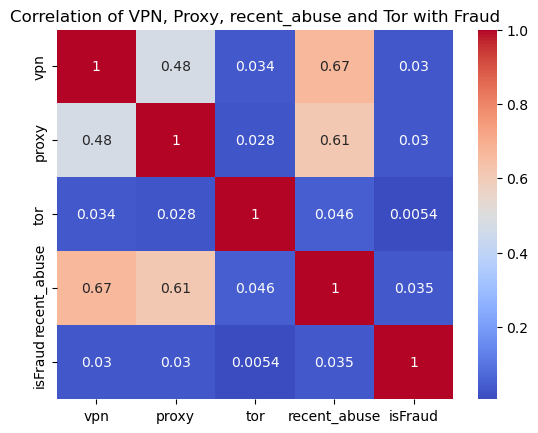

In [182]:
# Here we try to check if these columns have correlation with isFraud and also with other columns to know which is more relevant for our model or which to discard
corr_matrix = data[["vpn", "proxy", "tor", "recent_abuse","isFraud"]].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation of VPN, Proxy, recent_abuse and Tor with Fraud")
plt.show()

In [183]:
## This code snippet handles missing values in a set of binary features
data['proxy_vpn_flag'] = ((data['proxy'] == 1) | (data['vpn'] == 1)).astype(int)

Fraudsters often use VPNs, proxies, and Tor to hide their identities. While these features have low correlation with fraud, they show strong correlation with each other. To capture their combined risk, we created proxy_vpn_flag, a binary indicator. Despite 49% missing data, we retained them for their fraud detection potential.

In [184]:
# Fill missing categorical values with "Unknown" for potential feature importance.
categorical_features = ['payer_name', 'channel', 'usr_name', 'payer_country']
data[categorical_features] = data[categorical_features].fillna("Unknown")

In [185]:
# Flag payer/nationality mismatches for fraud detection.
data["payer_country_mismatch"] = (data["payer_country"] != data["nationality"]).astype(int)
data["name_mismatch"] = (data["payer_name"] != data["usr_name"]).astype(int)

.

It's common for fraudsters to make multiple payment attempts, especially if their initial attempts are declined. Legitimate users might occasionally make a couple of retries, but a significantly higher number of attempts can be a red flag.

In [186]:
# A high number of payment attempts may suggest suspicious activity,  
data['high_payment_attempts'] = (data['p_attempts'] > 3).astype(int)

#### Since passenger_score, email_domain_score and passenger_passport_score has only two values , converting it to a binary feature (0 or 1) makes it easier for the model to interpret without adding unnecessary complexity.

In [188]:
data['passenger_score_flag'] = (data['passenger_score'] > 0).astype(int)
data['passenger_passport_score_flag'] = (data['passenger_passport_score'] > 0).astype(int)
data['email_domain_score_flag'] = (data['email_domain_score'] > 0).astype(int)

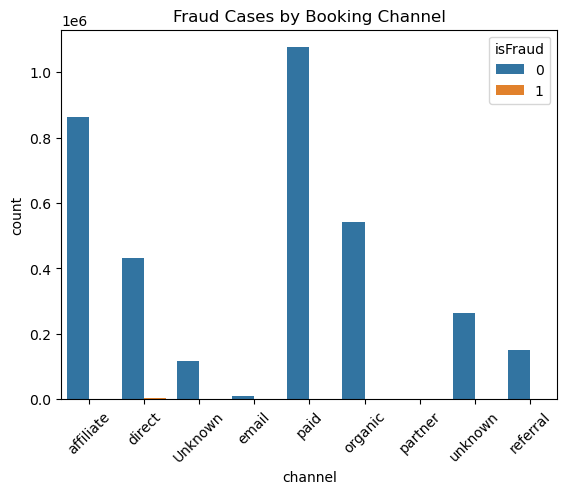

In [189]:
# Visualize fraud distribution across booking channels.
sns.countplot(x="channel", hue="isFraud", data=data)
plt.title("Fraud Cases by Booking Channel")
plt.xticks(rotation=45)
plt.show()


In [59]:
data.head(5)

,bid,channel,createdon,cust_name,date_of_birth,email,email_domain_score,email_score,godate,insurance_flg,ip,isFraud,nationality,netprice_thb,p_attempts,paidon,passenger_passport_score,passenger_score,payer_country,payer_name,proxy,recent_abuse,role_id,seats,tor,useragent,usr_name,vehclass_id,vpn,netprice_thb_log,high_price_flag,age,age_group,time_to_payment,days_to_travel,booking_hour,weekday,email_domain,email_domain_type,high_risk_domain_flag,proxy_vpn_flag,payer_country_mismatch,name_mismatch,high_payment_attempts,passenger_score_flag,passenger_passport_score_flag,email_domain_score_flag,role_fraud_rate
0,6524445,affiliate,2021-05-01 00:21:17+07:00,Tiffany Stephenson,1999-07-04,ryanbrianna@outlook.com,0.0,10.0,2021-07-01 07:30:00+07:00,0,213.89.6.2,0,SE,115.000000,0,2021-06-29 16:57:12.177348+07:00,0.0,0.0,SE,Tiffany Stephenson,0.0,0.0,user,1,0.0,"Phone,sv,SEK",Tiffany Stephenson,van,0.0,4.753590,0,26.0,18-30,59.0,61.297720,0,5,outlook.com,common,0,0,0,0,0,0,0,0,0.002261
1,5800338,affiliate,2021-05-01 00:30:19+07:00,Amanda Cooper,2002-06-07,dustin85@gmail.com,0.0,10.0,2021-05-29 13:35:00+07:00,1,124.106.133.175,0,TH,985.180176,0,2021-05-25 03:58:15.692073+07:00,0.0,0.0,NU,Unknown,0.0,0.0,user,1,0.0,"Phone,en,PHP",Amanda Cooper,avia,0.0,6.893839,0,23.0,18-30,24.0,28.544919,0,5,gmail.com,common,0,0,1,1,0,0,0,0,0.002261
2,7897646,direct,2021-05-01 01:09:12+07:00,Victoria Cortez,NaN,johnny40@gmail.com,0.0,2.0,2021-05-10 10:40:00+07:00,1,183.88.101.237,0,TH,2400.000000,7,2021-05-05 18:40:55.424451+07:00,0.0,0.0,CH,Victoria Cortez,0.0,0.0,user,2,0.0,"Phone,de,THB",Victoria Cortez,avia,0.0,7.783641,1,31.0,30-50,4.0,9.396389,1,5,gmail.com,common,0,0,1,0,1,0,0,0,0.002261
3,7644834,direct,2021-05-01 01:29:33+07:00,Victoria Cortez,1995-08-02,johnny40@gmail.com,0.0,2.0,2021-05-10 12:00:00+07:00,1,183.88.101.237,0,TH,410.000000,2,2021-05-06 04:07:31.171406+07:00,0.0,0.0,CH,Victoria Cortez,0.0,0.0,user,2,0.0,"Phone,de,THB",Victoria Cortez,bus,0.0,6.018593,0,30.0,18-30,5.0,9.437812,1,5,gmail.com,common,0,0,1,0,0,0,0,0,0.002261
4,7462960,Unknown,2021-05-01 01:36:36+07:00,Francisco Wagner,1989-01-16,margaretcastaneda@gmail.com,0.0,5.0,2021-05-02 10:33:00+07:00,1,183.171.184.148,0,TH,573.537903,0,2021-04-27 17:24:15.421043+07:00,0.0,0.0,NU,Unknown,0.0,0.0,user,1,0.0,"Phone,en,MYR",Francisco Wagner,train,0.0,6.353566,0,36.0,30-50,-4.0,1.372500,1,5,gmail.com,common,0,0,1,1,0,0,0,0,0.002261


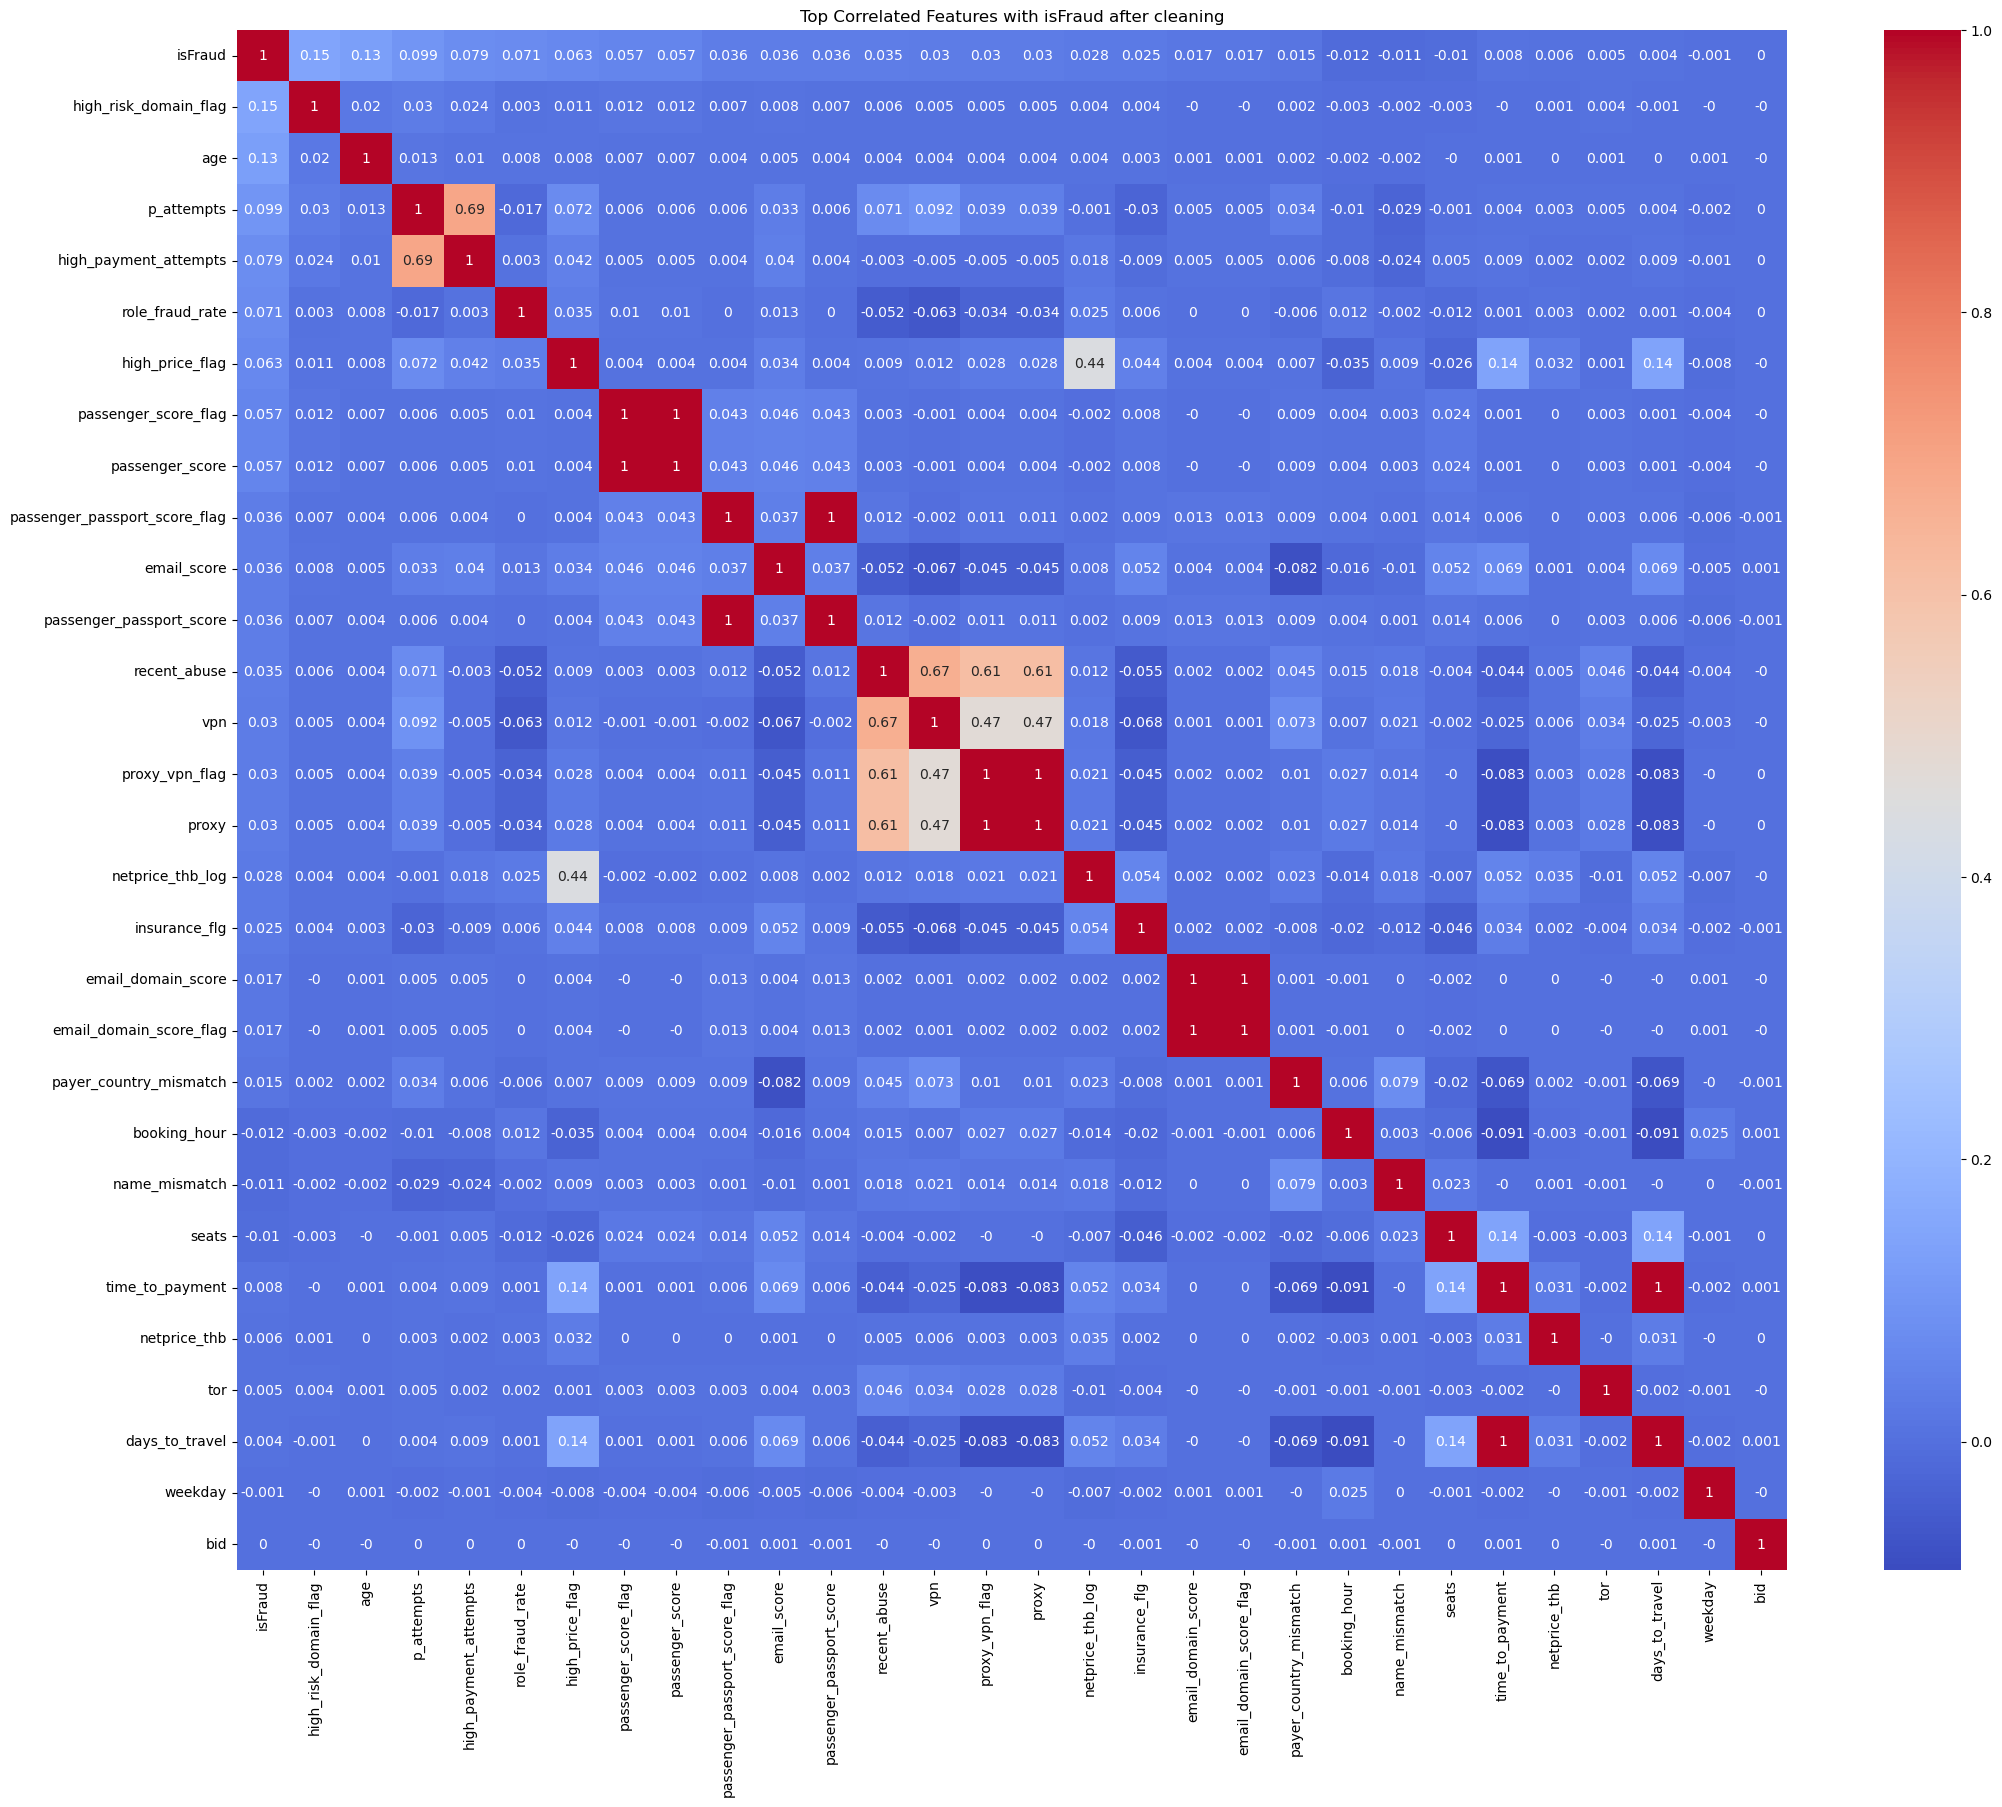

In [60]:
# Select numerical columns
corr=data.select_dtypes(include=['number']).columns

# Compute correlation matrix
corr_matrix = data[corr].corr().round(3)

# Sort correlation values with 'isFraud'
top_corr_feat= corr_matrix[['isFraud']].abs().sort_values(by='isFraud', ascending=False)
# Plot heatmap for top correlated features
plt.figure(figsize=(25, 20))
sns.heatmap(corr_matrix[top_corr_feat.index].loc[top_corr_feat.index], annot=True, cmap='coolwarm')
plt.title("Top Correlated Features with isFraud after cleaning")
plt.savefig("chart.png", dpi=300, bbox_inches="tight")
plt.show()

In [191]:
## We drop a set of features likely to address multicollinearity, redundancy, or other issues that might hinder model performance
drop_features = ["bid","createdon","cust_name",
                 "date_of_birth","email","godate",
                 "nationality","paidon","payer_country",
                 "usr_name","vehclass_id","email_domain_score",
                 "proxy", "vpn" ,"passenger_passport_score","passenger_score" ,
                 "email_domain","payer_name", "useragent","ip","netprice_thb","age","days_to_travel"
                ]
# Droping  IP because of it's high-cardinality and not useful in raw form

data_cleaned = data.drop(columns=drop_features)
data_cleaned

,channel,email_score,insurance_flg,isFraud,p_attempts,recent_abuse,role_id,seats,tor,netprice_thb_log,high_price_flag,age_group,time_to_payment,booking_hour,weekday,email_domain_type,high_risk_domain_flag,role_fraud_rate,proxy_vpn_flag,payer_country_mismatch,name_mismatch,high_payment_attempts,passenger_score_flag,passenger_passport_score_flag,email_domain_score_flag
0,affiliate,10.0,0,0,0,0.0,user,1,0.0,4.753590,0,18-30,59.0,0,5,common,0,0.002261,0,0,0,0,0,0,0
1,affiliate,10.0,1,0,0,0.0,user,1,0.0,6.893839,0,18-30,24.0,0,5,common,0,0.002261,0,1,1,0,0,0,0
2,direct,2.0,1,0,7,0.0,user,2,0.0,7.783641,1,30-50,4.0,1,5,common,0,0.002261,0,1,0,1,0,0,0
3,direct,2.0,1,0,2,0.0,user,2,0.0,6.018593,0,18-30,5.0,1,5,common,0,0.002261,0,1,0,0,0,0,0
4,Unknown,5.0,1,0,0,0.0,user,1,0.0,6.353566,0,30-50,-4.0,1,5,common,0,0.002261,0,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3464217,affiliate,0.0,0,0,0,0.0,user,2,0.0,5.993961,0,18-30,69.0,4,2,common,0,0.002261,1,1,1,0,0,0,0
3464218,affiliate,0.0,0,0,0,0.0,user,2,0.0,5.638355,0,18-30,74.0,4,2,common,0,0.002261,1,1,1,0,0,0,0
3464219,affiliate,0.0,0,0,0,0.0,user,2,0.0,6.585571,0,18-30,158.0,4,2,common,0,0.002261,1,1,1,0,0,0,0
3464220,unknown,0.0,0,0,0,0.0,user,2,0.0,6.542472,0,30-50,-2.0,4,2,other,0,0.002261,0,0,1,0,0,0,0


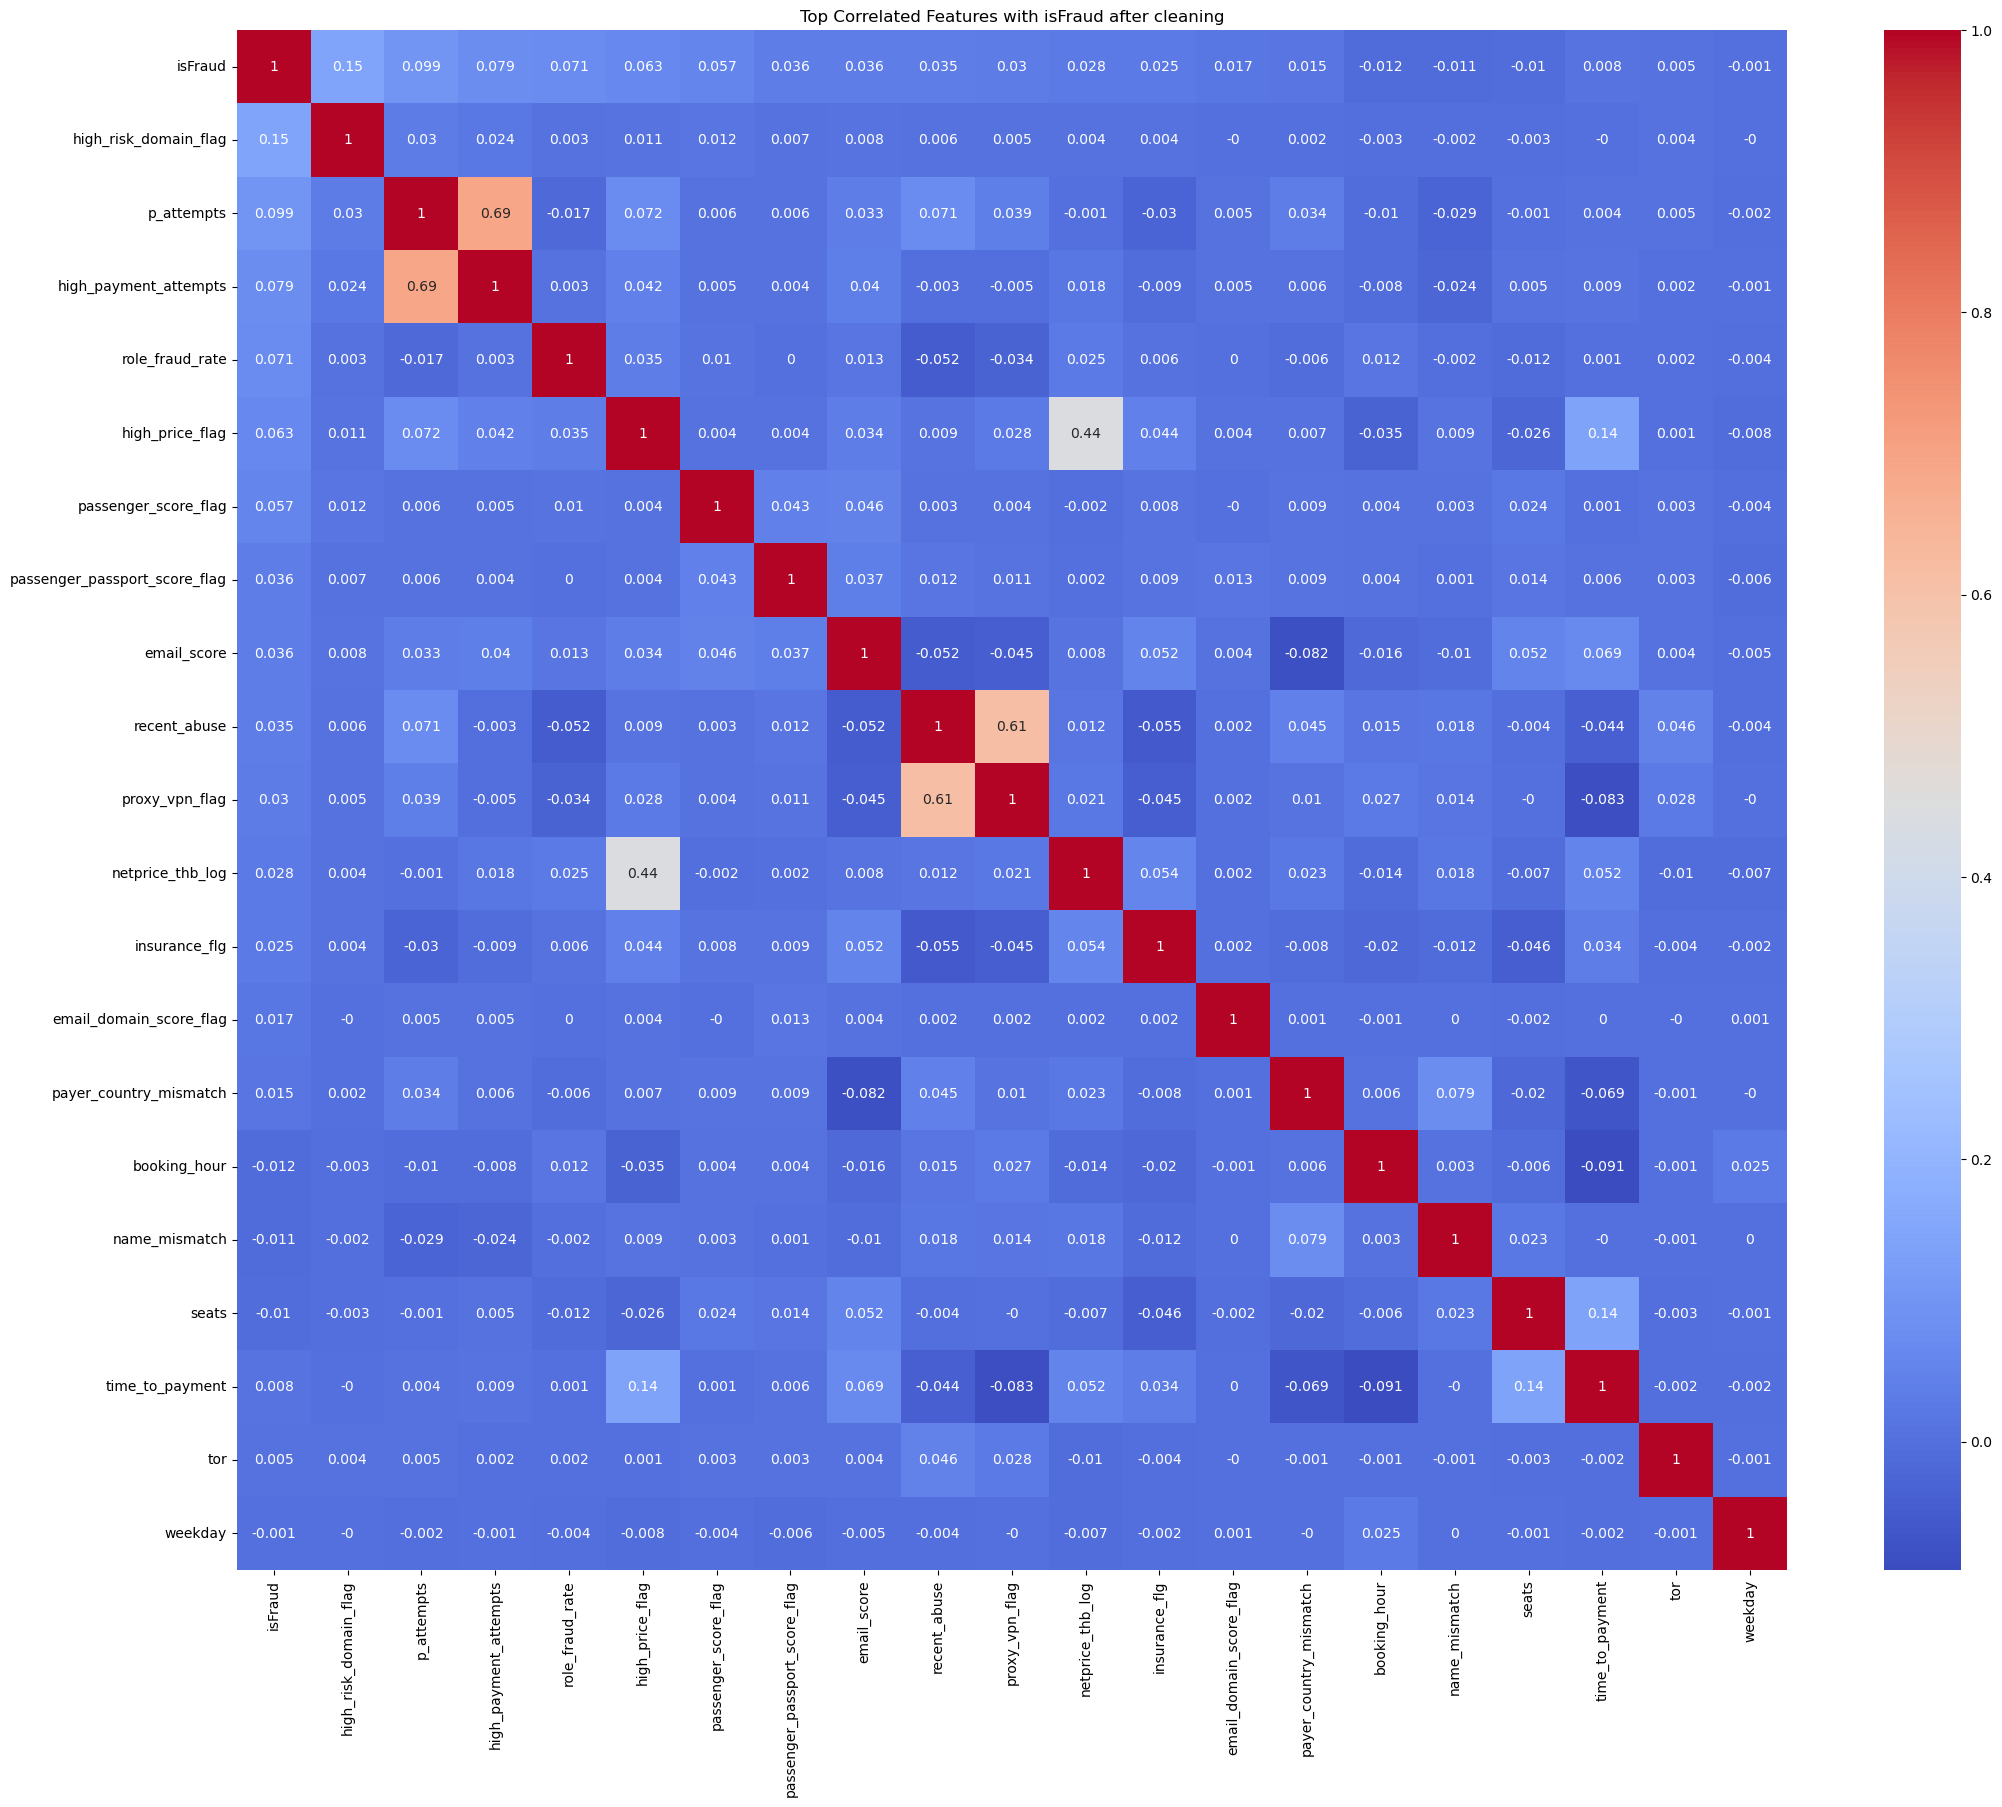

In [136]:
## checking our data after dropping these columns
corr=data_cleaned.select_dtypes(include=['number']).columns

# Compute correlation matrix
corr_matrix = data_cleaned[corr].corr().round(3)

# Sort correlation values with 'isFraud'
top_corr_feat= corr_matrix[['isFraud']].abs().sort_values(by='isFraud', ascending=False)
# Plot heatmap for top correlated features
plt.figure(figsize=(25, 20))
sns.heatmap(corr_matrix[top_corr_feat.index].loc[top_corr_feat.index], annot=True, cmap='coolwarm')
plt.title("Top Correlated Features with isFraud after cleaning")
plt.savefig("chart.png", dpi=300, bbox_inches="tight")
plt.show()

In [192]:

### encoding categorical columns
from sklearn.preprocessing import LabelEncoder
# Encode categorical variables
label_encoders = {}
categorical_cols = ["channel", "role_id", "email_domain_type","age_group",]

for col in categorical_cols:
    le = LabelEncoder()
    data_cleaned[col] = le.fit_transform(data_cleaned[col])
    label_encoders[col] = le


In [193]:
##dropping null rows 
data_cleaned= data_cleaned.dropna(axis=0)

In [203]:
### importing necessary libraries for modelling
import numpy as np
import plotly.express as px
from sklearn.feature_selection import RFE
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [195]:
#Calculating the baseline accuracy score for the model.
acc_baseline = data_cleaned["isFraud"].value_counts(normalize=True)
print("Baseline Accuracy:", round(acc_baseline, 4))

Baseline Accuracy: isFraud
0    0.9977
1    0.0023
Name: proportion, dtype: float64


In [196]:
## creating our feature variable and target variable
target  ="isFraud"
X = data_cleaned.drop(columns=target)
y = data_cleaned[target]

In [197]:
##splitting the features and target variable
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42, test_size=0.2)
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2771310, 24)
y_train shape: (2771310,)
X_test shape: (692828, 24)
y_test shape: (692828,)


In [198]:
##using randomforestclassifier to extract features that are more important to model from our dataset
rf = RandomForestClassifier(n_estimators=50, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=50, random_state=42)

In [201]:
##extraction of feature importance
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
selected_features = importances.nlargest(10).index
X_train_imp = X_train[selected_features]
X_test_imp = X_test[selected_features]

In [204]:
##standardizing our data before SMOTE ensures fair distance calculations 
scaler = StandardScaler()
X_train_selected = scaler.fit_transform(X_train_imp)
X_test_selected = scaler.fit_transform(X_test_imp)
X_test_selected

array([[ 0.41092434, -0.29078488, -0.283497  , ...,  0.42026304,
        -0.80275059,  2.49684099],
       [ 0.41092434,  0.33886387,  0.18211992, ...,  1.69207434,
         0.15702204, -0.40050608],
       [-0.81723617, -0.4212064 , -0.42676375, ...,  1.69207434,
         0.15702204, -0.40050608],
       ...,
       [-0.81723617,  0.20586856, -0.35513037, ..., -0.34282373,
        -0.80275059,  2.49684099],
       [-0.81723617,  0.68104985, -0.42676375, ...,  1.69207434,
         0.15702204, -0.40050608],
       [-0.81723617,  0.15459292, -0.42676375, ...,  1.69207434,
        -0.80275059, -0.40050608]])

In [205]:
## since we have an imbalance dataset its SMOTE is an effective way to improve performance 
smote = SMOTE( random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_selected, y_train)

In [206]:
# we used XGBClassifier
xgb = XGBClassifier(scale_pos_weight=434, random_state=42)

In [207]:
## setting parameters for our model
param_grid = {
    'n_estimators': np.arange(50, 101, 10),
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1, 0.2]
}

In [208]:
model = RandomizedSearchCV(estimator=xgb,
                           param_distributions=param_grid,
                            scoring='f1',
                           cv=5,  
                           n_jobs=-1, 
                           verbose=1)

In [209]:
model.fit(X_train_smote,y_train_smote)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           gamma=None, grow_policy=None,
                                           importance_type=None,
                                           interaction_constraints=None,
                                           learning_rate...
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None,
                                           random_state=42, ...),
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 1.0],
                                        'gamma': [0, 0.1, 0.2],
                                        'learning_rate': [0.01, 0.1, 0.3],
                                        'max_depth': [3, 6, 9],
                                        'n_estimators': array([ 50,  60,  70,  80,  90, 100]),
                                        'subsample': [0.8, 1]},
                   scoring='f1', verbose=1)

In [210]:
best_model = model.best_estimator_
print("Best Model Parameters:", model.best_params_)

Best Model Parameters: {'subsample': 1, 'n_estimators': 100, 'max_depth': 9, 'learning_rate': 0.3, 'gamma': 0.1, 'colsample_bytree': 0.8}


In [212]:
y_pred = best_model.predict(X_test_selected)
y_pred_proba = best_model.predict_proba(X_test_selected)[:, 1] 

In [213]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nAUC-ROC Score:", roc_auc_score(y_test, y_pred_proba))


Confusion Matrix:
 [[634177  57050]
 [   190   1411]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.92      0.96    691227
           1       0.02      0.88      0.05      1601

    accuracy                           0.92    692828
   macro avg       0.51      0.90      0.50    692828
weighted avg       1.00      0.92      0.95    692828


AUC-ROC Score: 0.9503802292203727


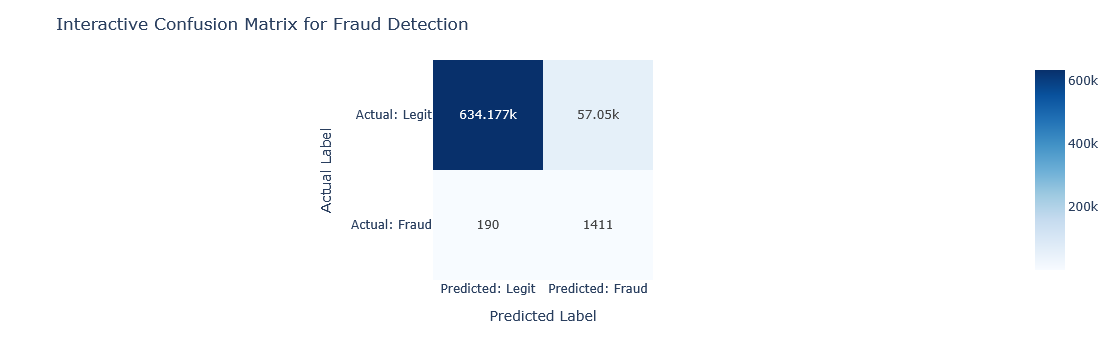

In [215]:
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=['Actual: Legit', 'Actual: Fraud'], 
                         columns=['Predicted: Legit', 'Predicted: Fraud'])

# Create an interactive confusion matrix using plotly
fig = px.imshow(cm_df, text_auto=True, color_continuous_scale='Blues')

# Update layout for clarity
fig.update_layout(
    title='Interactive Confusion Matrix for Fraud Detection',
    xaxis_title="Predicted Label",
    yaxis_title="Actual Label"
)

# Show the interactive plot
fig.show()